# Slot-Filling Evaluation

Evaluates the FashionAI slot-filling extractor against a hand-authored natural-language dataset.

- **Model:** OpenAI chat completions (default `gpt-4o-mini`).
- **Dataset:** `dataset.jsonl` — 50+ cases across 9 categories.
- **Output:** `report.json` + `report.md` + `report.xlsx` + inline charts for the final project report.

## 1. Setup

In [1]:
import hashlib, json, os, re
from pathlib import Path

from dotenv import load_dotenv
from openai import OpenAI
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

HERE = Path.cwd()
REPO_ROOT = next(p for p in [HERE, *HERE.parents] if (p / '.env').exists() or (p / '.git').exists())
load_dotenv(REPO_ROOT / '.env')

OPENAI_API_KEY = os.environ['OPENAI_API_KEY']
OPENAI_MODEL = os.environ.get('OPENAI_MODEL', 'gpt-4o-mini')

client = OpenAI(api_key=OPENAI_API_KEY)
MODEL_ID = OPENAI_MODEL
print(f'Model: {MODEL_ID}')

Model: gpt-4o-mini


## 2. Extractor (direct OpenAI call, JSON output)

One request per call. Uses `response_format={"type":"json_object"}` so the model is constrained to return JSON — no LangChain, no tool-calling, no retries.

In [2]:
KNOWN_OCCASIONS = ['Casual', 'Formal', 'Sport', 'Party']
KNOWN_COLORS = ['Black','White','Grey','Blue','Red','Pink','Green','Yellow',
                'Orange','Purple','Beige','Brown','Turquoise','Gold','Silver']
KNOWN_MONTHS = ['January','February','March','April','May','June',
                'July','August','September','October','November','December']
REQUIRED_SLOTS = ['occasion','destination','month','gender','num_outfits',
                  'max_price','preferred_colors','avoid_colors']

SYSTEM_PROMPT = f'''You are a slot-filling NLU module for a fashion recommender.
Extract the following slots from the user message and return STRICT JSON only.

Schema (use null for unknown scalars, [] for unknown lists):
{{
  "occasion": one of {KNOWN_OCCASIONS} or null,
  "destination": city/place string or null,
  "month": one of {KNOWN_MONTHS} or null,
  "gender": "male" or "female" or null,
  "num_outfits": integer 1..5 or null,
  "max_price": number (SGD upper bound) or null,
  "preferred_colors": list of colours from {KNOWN_COLORS},
  "avoid_colors": list of colours from {KNOWN_COLORS},
  "refused_target": boolean (true only if user explicitly declined to answer the current question)
}}

Mapping rules:
- Occasion synonyms: date/chilling/holiday -> Casual; wedding/interview/business/conference -> Formal;
  clubbing/birthday/party -> Party; hiking/gym/running/sport -> Sport.
- Gender phrasing: guy/dude/man/male/menswear -> male; lady/woman/female/ladieswear -> female.
- Destination aliases: SG -> Singapore, NYC -> New York, LA -> Los Angeles, KL -> Kuala Lumpur, HK -> Hong Kong.
- Budget: extract numeric upper bound. "around 200" -> 200, "under 150" -> 150, "no more than $300" -> 300.
- Colour synonyms map to closest palette entry: navy->Blue, cream/ivory/tan->Beige, khaki->Green,
  crimson/maroon->Red, lavender/mauve->Purple, magenta->Pink, teal->Turquoise, lime->Green.
- Refusals: if the user says "skip", "no preference", "any", "you choose", "whatever" for the current
  question (target_slot), set refused_target=true. Do NOT fill that slot in that case.'''

def extract_slots(message: str, target_slot: str | None = None) -> dict:
    user = f'target_slot: {target_slot or "unknown"}\nuser_message: {message}\nReturn JSON only.'
    resp = client.chat.completions.create(
        model=MODEL_ID,
        temperature=0.0,
        response_format={'type': 'json_object'},
        messages=[{'role':'system','content':SYSTEM_PROMPT},{'role':'user','content':user}],
    )
    text = resp.choices[0].message.content or '{}'
    m = re.search(r'\{.*\}', text, re.DOTALL)
    return json.loads(m.group(0)) if m else {}

# Smoke test
extract_slots('Casual trip to Tokyo in June, menswear, 3 outfits under $200, like blue and black, avoid pink.')

{'occasion': 'Casual',
 'destination': 'Tokyo',
 'month': 'June',
 'gender': 'male',
 'num_outfits': 3,
 'max_price': 200,
 'preferred_colors': ['Blue', 'Black'],
 'avoid_colors': ['Pink'],
 'refused_target': False}

## 3. Merge into SlotState-style dict

In [3]:
def empty_state() -> dict:
    return {s: {'value': None, 'filled': False, 'refused': False} for s in REQUIRED_SLOTS}

def merge(state: dict, target_slot: str | None, r: dict) -> None:
    if r.get('refused_target') and target_slot:
        state[target_slot] = {'value': None, 'filled': False, 'refused': True}
    mapping = [
        ('occasion', r.get('occasion')),
        ('destination', r.get('destination')),
        ('month', r.get('month')),
        ('gender', r.get('gender')),
    ]
    for k, v in mapping:
        if v:
            state[k] = {'value': v, 'filled': True, 'refused': False}
    if r.get('num_outfits') is not None:
        n = max(1, min(5, int(r['num_outfits'])))
        state['num_outfits'] = {'value': n, 'filled': True, 'refused': False}
    if r.get('max_price') is not None:
        state['max_price'] = {'value': float(r['max_price']), 'filled': True, 'refused': False}
    pc = r.get('preferred_colors')
    if pc is not None and (pc or target_slot == 'preferred_colors'):
        state['preferred_colors'] = {'value': pc, 'filled': True, 'refused': False}
    ac = r.get('avoid_colors')
    if ac is not None and (ac or target_slot == 'avoid_colors'):
        state['avoid_colors'] = {'value': ac, 'filled': True, 'refused': False}

def next_empty(state: dict) -> str | None:
    for s in REQUIRED_SLOTS:
        if not (state[s]['filled'] or state[s]['refused']):
            return s
    return None

## 4. Load dataset

In [4]:
DATASET = HERE / 'dataset.jsonl'
cases = [json.loads(l) for l in DATASET.read_text(encoding='utf-8').splitlines() if l.strip()]
DATASET_HASH = hashlib.sha1(DATASET.read_bytes()).hexdigest()[:8]
print(f'{len(cases)} cases, hash {DATASET_HASH}')
pd.Series([c['category'] for c in cases]).value_counts().to_frame('count')

48 cases, hash d7ef5f10


,count
full-oneshot,10
occasion-mapping,10
gender-phrasing,5
destination-alias,5
budget-phrasing,5
colour-synonym,5
partial-followup,5
out-of-palette,3


## 5. Run evaluation

~1 request per turn. 50 single-turn + 5 two-turn cases = ~60 requests.

In [5]:
evaluated = []
for i, case in enumerate(cases, 1):
    state = empty_state()
    for turn in case['turns']:
        target = next_empty(state) or REQUIRED_SLOTS[0]
        try:
            r = extract_slots(turn, target)
            merge(state, target, r)
        except Exception as e:
            print(f'  ! {case["id"]} turn error: {e}')
    evaluated.append({
        'id': case['id'],
        'category': case['category'],
        'ground_truth': case['ground_truth'],
        'predicted': state,
        'num_turns': len(case['turns']),
    })
    print(f'{i:3d}/{len(cases)} {case["id"]}')
print('Done.')

  1/48 oneshot-01
  2/48 oneshot-02
  3/48 oneshot-03
  4/48 oneshot-04
  5/48 oneshot-05
  6/48 oneshot-06
  7/48 oneshot-07
  8/48 oneshot-08
  9/48 oneshot-09
 10/48 oneshot-10
 11/48 occ-01
 12/48 occ-02
 13/48 occ-03
 14/48 occ-04
 15/48 occ-05
 16/48 occ-06
 17/48 occ-07
 18/48 occ-08
 19/48 occ-09
 20/48 occ-10
 21/48 gen-01
 22/48 gen-02
 23/48 gen-03
 24/48 gen-04
 25/48 gen-05
 26/48 dest-01
 27/48 dest-02
 28/48 dest-03
 29/48 dest-04
 30/48 dest-05
 31/48 bud-01
 32/48 bud-02
 33/48 bud-03
 34/48 bud-04
 35/48 bud-05
 36/48 col-01
 37/48 col-02
 38/48 col-03
 39/48 col-04
 40/48 col-05
 41/48 par-01
 42/48 par-02
 43/48 par-03
 44/48 par-04
 45/48 par-05
 46/48 oop-01
 47/48 oop-02
 48/48 oop-03
Done.


### Cache predictions to disk

Run the **save** cell once after a successful eval. On the next session, run the **load** cell instead of the eval loop above — skips the ~60 LLM calls.

In [6]:
# SAVE — run after a successful eval loop
(HERE / 'predictions.json').write_text(
    json.dumps(evaluated, indent=2, default=str), encoding='utf-8')
print(f'Saved {len(evaluated)} predictions to predictions.json')

Saved 48 predictions to predictions.json


In [7]:
# LOAD — run this instead of the eval loop when re-opening the notebook
evaluated = json.loads((HERE / 'predictions.json').read_text(encoding='utf-8'))
turns_by_id = {c['id']: c['turns'] for c in cases}
print(f'Loaded {len(evaluated)} cached predictions')

Loaded 48 cached predictions


## 6. Compute metrics

In [8]:
import sys
sys.path.insert(0, str(HERE))
from metrics import compute_extended

report = compute_extended(evaluated)
report['model_id'] = MODEL_ID
report['dataset_hash'] = DATASET_HASH

print(f'Joint exact-match: {report["joint_exact_match"]}')
print(f'Refusal accuracy:  {report["refusal_accuracy"]}')

Joint exact-match: 0.9792
Refusal accuracy:  None


## 7. Per-slot accuracy

,slot,accuracy
0,occasion,1.0000
1,destination,1.0000
2,month,1.0000
3,gender,1.0000
4,num_outfits,1.0000
5,max_price,1.0000
6,preferred_colors,0.9792
7,avoid_colors,1.0000


,slot,precision,recall,f1
0,occasion,1.0000,1.0,1.0000
1,destination,1.0000,1.0,1.0000
2,month,1.0000,1.0,1.0000
3,gender,1.0000,1.0,1.0000
4,num_outfits,1.0000,1.0,1.0000
5,max_price,1.0000,1.0,1.0000
6,preferred_colors,0.9792,1.0,0.9895
7,avoid_colors,1.0000,1.0,1.0000


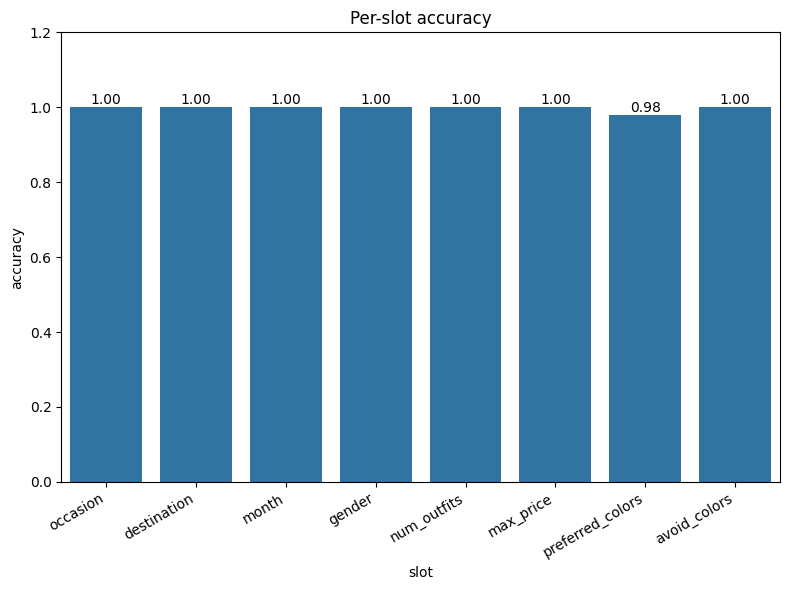

In [9]:
acc_df = pd.DataFrame(report['per_slot_accuracy'].items(), columns=['slot','accuracy'])
prf1_df = pd.DataFrame(report['per_slot_prf1']).T.reset_index().rename(columns={'index':'slot'})
display(acc_df)
display(prf1_df)

fig, ax = plt.subplots(figsize=(8,6))
sns.barplot(data=acc_df, x='slot', y='accuracy', ax=ax)
ax.set_ylim(0, 1.2)
ax.set_title('Per-slot accuracy')
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}', (p.get_x()+p.get_width()/2, p.get_height()), ha='center', va='bottom')
plt.xticks(rotation=30, ha='right'); plt.tight_layout()
plt.show()

## 8. Per-category accuracy

,category,accuracy
0,full-oneshot,1.0
1,occasion-mapping,1.0
2,gender-phrasing,1.0
3,destination-alias,1.0
4,budget-phrasing,1.0
5,colour-synonym,0.8
6,partial-followup,1.0
7,out-of-palette,1.0


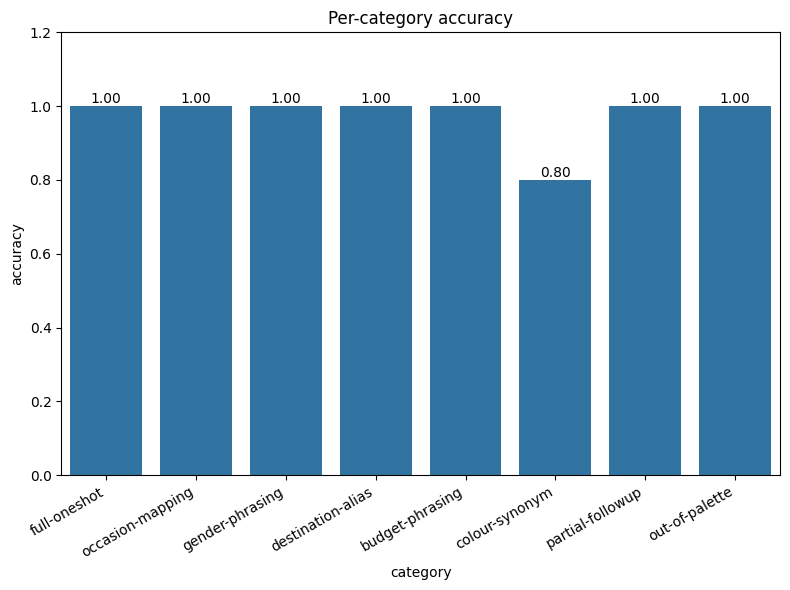

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Build DataFrame (same pattern as per-slot)
cat_acc_df = pd.DataFrame(
    report['per_category_accuracy'].items(),
    columns=['category', 'accuracy']
)

display(cat_acc_df)

# Plot (same style as per-slot)
fig, ax = plt.subplots(figsize=(8,6))

sns.barplot(
    data=cat_acc_df,
    x='category',
    y='accuracy',
    ax=ax
)

ax.set_ylim(0, 1.2)
ax.set_title('Per-category accuracy')

# Annotate bars (same logic)
for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.2f}',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom'
    )

plt.xticks(rotation=30, ha='right')
plt.tight_layout()

plt.show()

## 9. Occasion confusion matrix

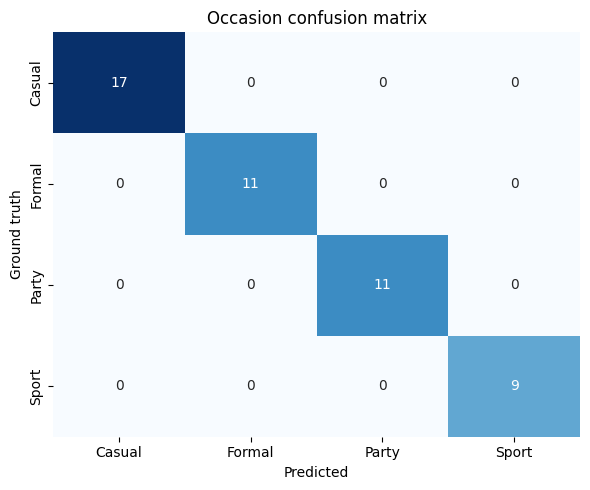

,Casual,Formal,Party,Sport
Casual,17,0,0,0
Formal,0,11,0,0
Party,0,0,11,0
Sport,0,0,0,9


In [11]:
conf = report['occasion_confusion']
labels = sorted(set(conf.keys()) | {p for row in conf.values() for p in row.keys()})
mat = pd.DataFrame(0, index=labels, columns=labels, dtype=int)
for gt, row in conf.items():
    for pred, n in row.items():
        mat.loc[gt, pred] = n

fig, ax = plt.subplots(figsize=(6,5))
sns.heatmap(mat, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax)
ax.set_xlabel('Predicted'); ax.set_ylabel('Ground truth')
ax.set_title('Occasion confusion matrix')
plt.tight_layout()
plt.show()
mat

## 10. Error inspection

Cases where joint exact-match failed, for the report narrative.

In [12]:
from metrics import slot_matches, ALL_SLOTS

def case_errors(c):
    errs = []
    for s in ALL_SLOTS:
        if s not in c['ground_truth']:
            continue
        p = c['predicted'].get(s, {})
        if not slot_matches(s, p.get('value'), bool(p.get('refused')), c['ground_truth'][s]):
            errs.append(f'{s}: got={p.get("value")} expected={c["ground_truth"][s]}')
    return errs

err_rows = [{'id': c['id'], 'category': c['category'], 'turns': ' | '.join(c.get('turns',[])) if 'turns' in c else '', 'errors': '; '.join(case_errors(c))}
            for c in evaluated if case_errors(c)]
# Re-attach turns (they live on the original cases, not evaluated)
turns_by_id = {c['id']: c['turns'] for c in cases}
for row in err_rows:
    row['turns'] = ' | '.join(turns_by_id[row['id']])
err_df = pd.DataFrame(err_rows)
print(f'{len(err_df)} / {len(evaluated)} cases failed joint EM')
err_df

1 / 48 cases failed joint EM


,id,category,turns,errors
0,col-05,colour-synonym,"Casual Rome May, woman, 3 outfits around 200, ...",preferred_colors: got=['Beige'] expected=['Whi...


## 11. Export report

In [13]:
def write_report_md(r):
    lines = [
        '# Slot-Filling Evaluation Report',
        '',
        f'- **Model:** `{r["model_id"]}`',
        f'- **Dataset hash:** `{r["dataset_hash"]}`',
        f'- **Cases:** {r["n_cases"]}',
        f'- **Joint exact-match:** {r["joint_exact_match"]}',
        f'- **Refusal accuracy:** {r["refusal_accuracy"]}',
        f'- **Avg turns per case:** {r["avg_turns"]}',
        '',
        '## Per-slot accuracy', '', '| Slot | Accuracy |', '|---|---|',
    ]
    for s, a in r['per_slot_accuracy'].items():
        lines.append(f'| `{s}` | {a} |')
    lines += ['', '## Per-slot Precision / Recall / F1', '', '| Slot | P | R | F1 |', '|---|---|---|---|']
    for s, d in r['per_slot_prf1'].items():
        lines.append(f'| `{s}` | {d["precision"]} | {d["recall"]} | {d["f1"]} |')
    lines += ['', '## List-slot Jaccard', '', '| Slot | Jaccard |', '|---|---|']
    for s, j in r['list_slot_jaccard'].items():
        lines.append(f'| `{s}` | {j} |')
    lines += ['', '## Per-category accuracy', '', '| Category | Accuracy | Cases |', '|---|---|---|']
    for c, a in r['per_category_accuracy'].items():
        lines.append(f'| `{c}` | {a} | {r["category_counts"].get(c,0)} |')
    return '\n'.join(lines) + '\n'

(HERE / 'report.json').write_text(json.dumps(report, indent=2), encoding='utf-8')
(HERE / 'report.md').write_text(write_report_md(report), encoding='utf-8')
print('Wrote report.json + report.md')

Wrote report.json + report.md


## 12. Export to Excel

One `.xlsx` workbook with a sheet per view — drop into the final report.

In [14]:
xlsx_path = HERE / 'report.xlsx'

summary_df = pd.DataFrame([
    ('model_id', report['model_id']),
    ('dataset_hash', report['dataset_hash']),
    ('n_cases', report['n_cases']),
    ('joint_exact_match', report['joint_exact_match']),
    ('avg_turns', report['avg_turns']),
], columns=['metric','value'])

jaccard_df = pd.DataFrame(
    [(s, v) for s, v in report['list_slot_jaccard'].items()],
    columns=['slot','jaccard'])

# Predictions table — one row per case, GT and prediction side-by-side per slot.
rows = []
for c in evaluated:
    row = {'id': c['id'], 'category': c['category'],
           'turns': ' | '.join(turns_by_id[c['id']])}
    for s in REQUIRED_SLOTS:
        gt = c['ground_truth'].get(s)
        p = c['predicted'].get(s, {})
        row[f'{s}__gt'] = str(gt)
        row[f'{s}__pred'] = '__refused__' if p.get('refused') else str(p.get('value'))
    errs = case_errors(c)
    row['errors'] = '; '.join(errs)
    row['joint_correct'] = not errs
    rows.append(row)
predictions_df = pd.DataFrame(rows)

with pd.ExcelWriter(xlsx_path, engine='openpyxl') as xw:
    summary_df.to_excel(xw, sheet_name='summary', index=False)
    acc_df.to_excel(xw, sheet_name='per_slot_accuracy', index=False)
    prf1_df.to_excel(xw, sheet_name='per_slot_prf1', index=False)
    jaccard_df.to_excel(xw, sheet_name='list_slot_jaccard', index=False)
    cat_acc_df.to_excel(xw, sheet_name='per_category', index=False)
    mat.to_excel(xw, sheet_name='occasion_confusion')
    predictions_df.to_excel(xw, sheet_name='predictions', index=False)
    err_df.to_excel(xw, sheet_name='errors', index=False)

print(f'Wrote {xlsx_path}')

Wrote d:\Projects\fashion-recommender\services\agent-service\eval\slot_filling\report.xlsx
